In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split as ts
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.metrics import mean_absolute_percentage_error,r2_score

In [2]:
dataset= pd.read_csv("advertising.csv")

In [3]:
dataset.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [4]:
dataset.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [5]:
dataset.shape

(200, 4)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


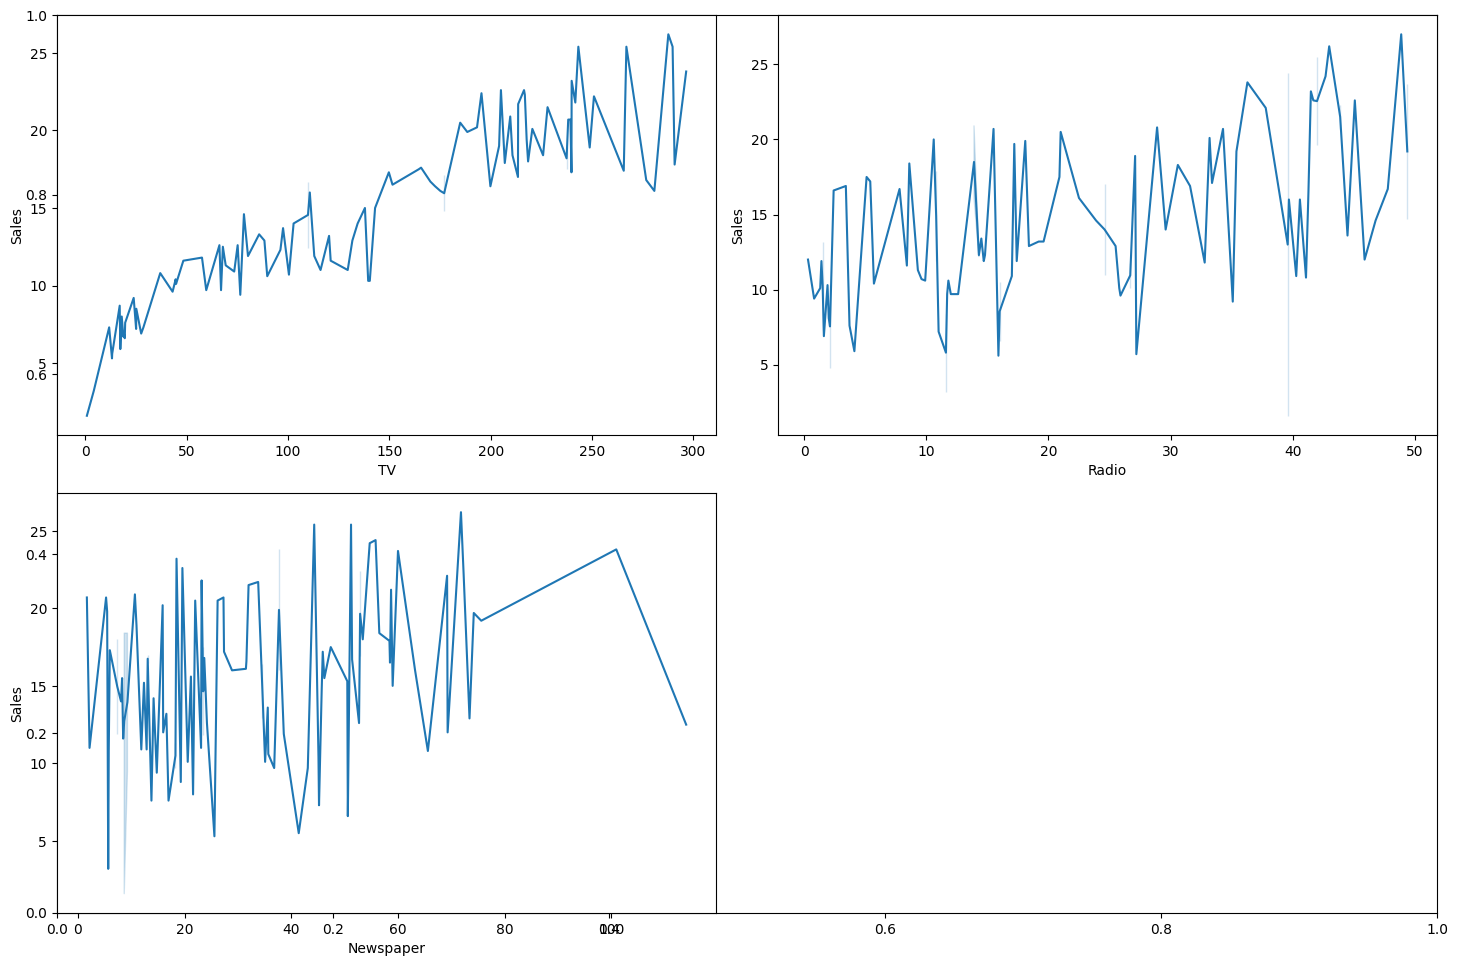

In [7]:
z=['TV','Radio','Newspaper']
plt.subplots(figsize=(15,10))
for i, col in enumerate(z):
    plt.subplot(2,2,i+1)
    x=dataset.sample(100)
    sb.lineplot(x=col,y='Sales',data=x)
plt.tight_layout()
plt.show()

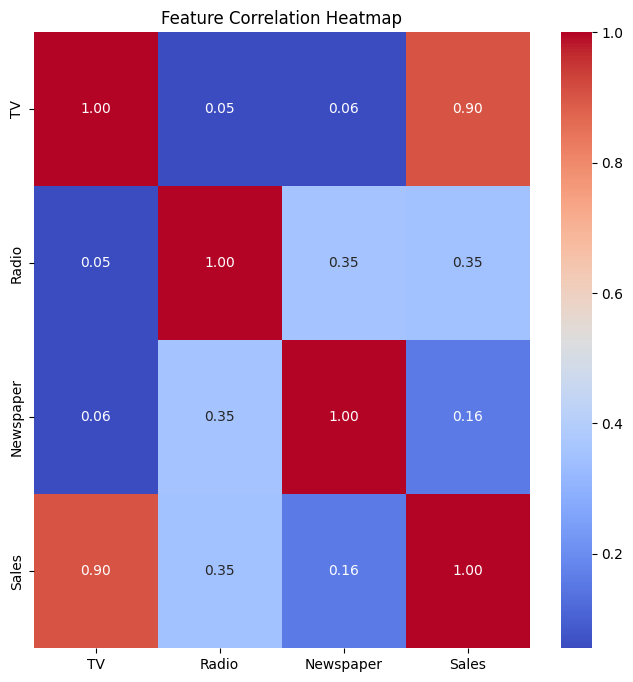

In [8]:
plt.figure(figsize=(8,8))
sb.heatmap(dataset.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
dataset.drop('Newspaper', axis=1, inplace=True)

In [10]:
dataset.head()
features= dataset.iloc[:,:-1].values
target=dataset.iloc[:,-1].values

In [11]:
x_train,x_test,y_train,y_test=ts(features,target,test_size=0.1,random_state=1)
print(x_train[:5])      # First 5 rows
print(x_train.shape)

[[100.4   9.6]
 [ 67.8  36.6]
 [ 25.1  25.7]
 [107.4  14. ]
 [112.9  17.4]]
(180, 2)


In [12]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [ ]:
rfr=RandomForestClassifier()

In [13]:
y_pred_lr=lr.predict(x_test)

In [14]:
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear MAPE:", mean_absolute_percentage_error(y_test, y_pred_lr))

Linear Regression R2: 0.8275140661493173
Linear MAPE: 0.08150395369982981


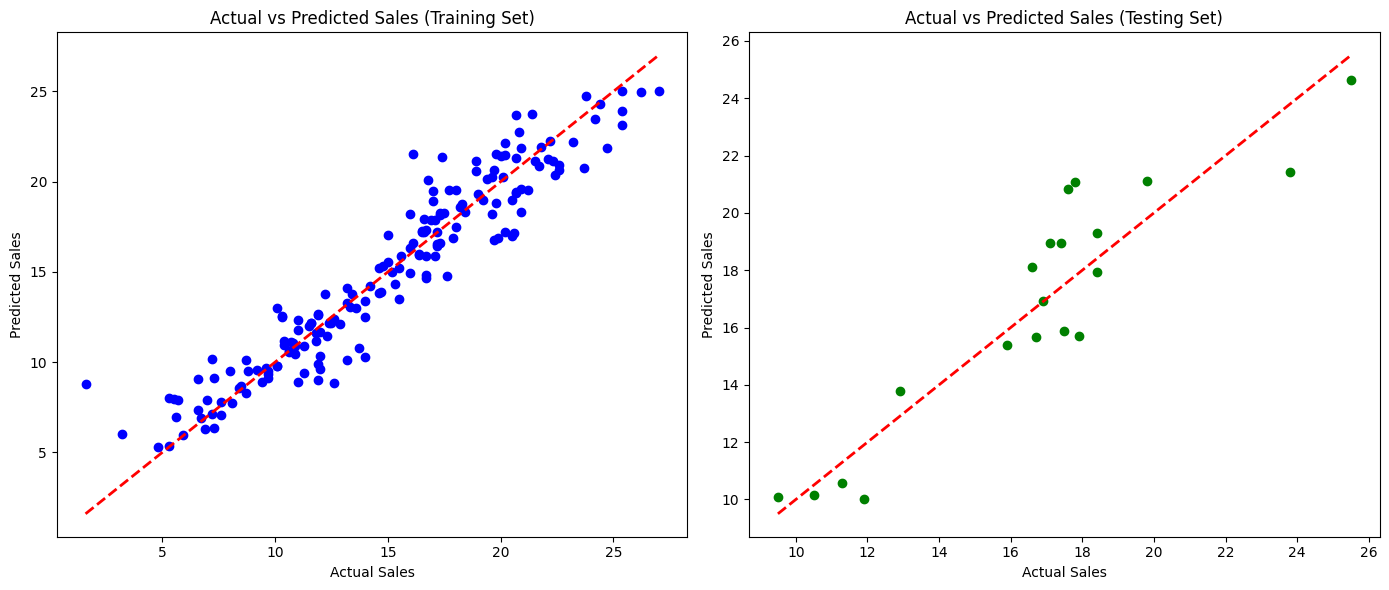

In [15]:
plt.figure(figsize=(14, 6))

# Training subplot
plt.subplot(1, 2, 1)
plt.scatter(y_train, lr.predict(x_train), color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', linewidth=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Training Set)")

# Testing subplot
plt.subplot(1, 2, 2)
plt.scatter(y_test, lr.predict(x_test), color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Testing Set)")

plt.tight_layout()
plt.show()
